<a href="https://colab.research.google.com/github/cosmic-code05/Heart_Disease_Predictor/blob/main/Heart_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [3]:
import os
os.listdir('/content')

['.config', 'heart.csv', '.ipynb_checkpoints', 'sample_data']

In [4]:
df = pd.read_csv('/content/heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(302, 14)

<Axes: xlabel='target'>

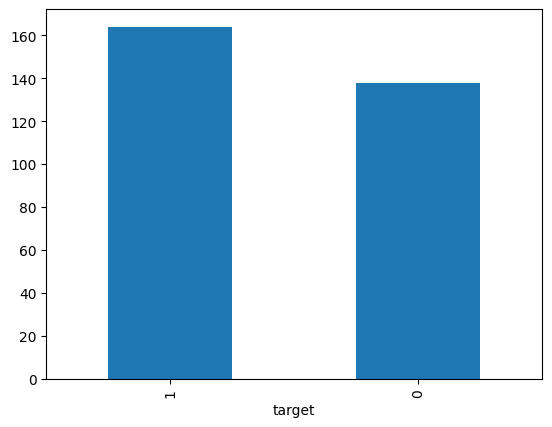

In [13]:
df['target'].value_counts().plot(kind='bar')

In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [15]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Note: Thalach is differing from all other graphs. Thalach AKA Maximum Heart Rate appears to have stronger relationship with the target compared with the other variables.

In [16]:
df['chol'].value_counts().sort_index().head()

,count
chol,
126,1
131,1
141,1
149,2
157,1


In [17]:
df['chol'].value_counts().sort_index().head(10)

,count
chol,
126,1
131,1
141,1
149,2
157,1
160,1
164,1
166,1
167,1


In [18]:
df['thalach'].value_counts().sort_index().head()

,count
thalach,
71,1
88,1
90,1
95,1
96,2


In [19]:
df['trestbps'].value_counts().sort_index().head()

,count
trestbps,
94,2
100,4
101,1
102,2
104,1


In [20]:
!pip install sheryanalysis==0.1.0

In [21]:
import sheryanalysis
sheryanalysis.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (302, 14)


...


🔠 Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


INFO:sheryanalysis:
🔠 Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']



🔢 Numerical Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


{'shape': (302, 14),
 'columns': ['age',
  'sex',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalach',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal',
  'target'],
 'dtypes': {'age': dtype('int64'),
  'sex': dtype('int64'),
  'cp': dtype('int64'),
  'trestbps': dtype('int64'),
  'chol': dtype('int64'),
  'fbs': dtype('int64'),
  'restecg': dtype('int64'),
  'thalach': dtype('int64'),
  'exang': dtype('int64'),
  'oldpeak': dtype('float64'),
  'slope': dtype('int64'),
  'ca': dtype('int64'),
  'thal': dtype('int64'),
  'target': dtype('int64')},
 'null_counts': {'age': 0,
  'sex': 0,
  'cp': 0,
  'trestbps': 0,
  'chol': 0,
  'fbs': 0,
  'restecg': 0,
  'thalach': 0,
  'exang': 0,
  'oldpeak': 0,
  'slope': 0,
  'ca': 0,
  'thal': 0,
  'target': 0},
 'total_rows': 302,
 'column_types': {'categorical': ['sex',
   'cp',
   'fbs',
   'restecg',
   'exang',
   'slope',
   'ca',
   'thal',
   'target'],
  'numerical': ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
  'd

In [22]:
df['sex_label'] = df['sex'].map({0: 'Female', 1:'Male'})

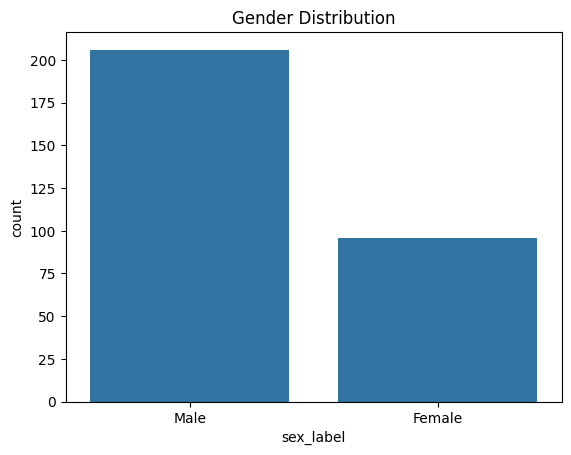

In [23]:
sns.countplot(x=df['sex_label'])
plt.title('Gender Distribution')
plt.show()

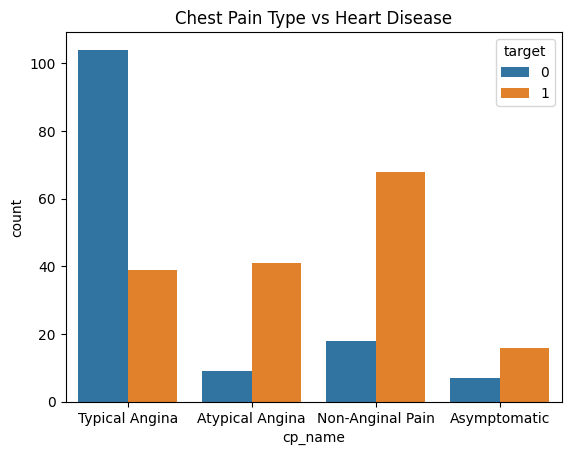

In [24]:
cp_names = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
}
df['cp_name'] = df['cp'].map(cp_names)
sns.countplot(x=df['cp_name'], hue=df['target'])
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [25]:
fbs_names = df['fbs'].map({0: '<= 120 mg/dl', 1: '>120 mg/dl'})
df['fbs_name'] = df['fbs'].map(fbs_names)

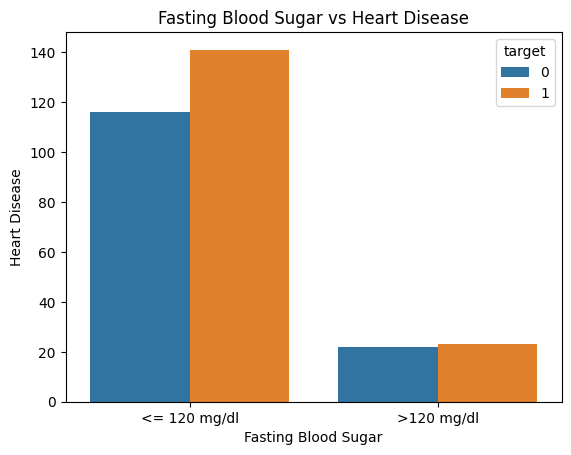

In [26]:
sns.countplot(x=df['fbs_name'],hue=df['target'])
plt.title('Fasting Blood Sugar vs Heart Disease')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Heart Disease')
plt.show()

<Axes: xlabel='target', ylabel='chol'>

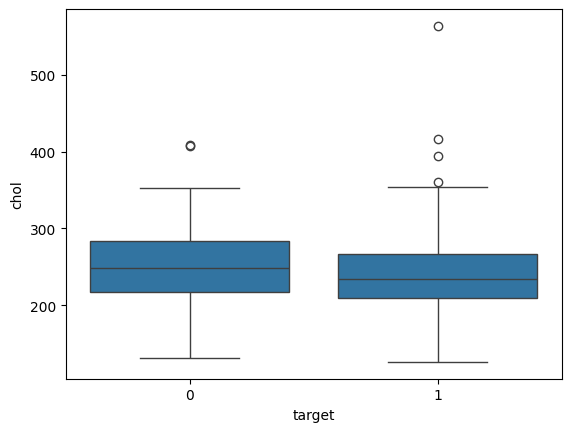

In [27]:
sns.boxplot(x='target', y='chol', data=df)

<Axes: xlabel='target', ylabel='age'>

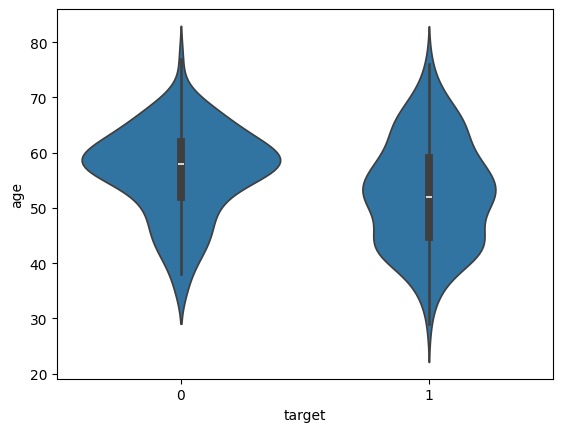

In [28]:
sns.violinplot(x='target', y='age', data=df)

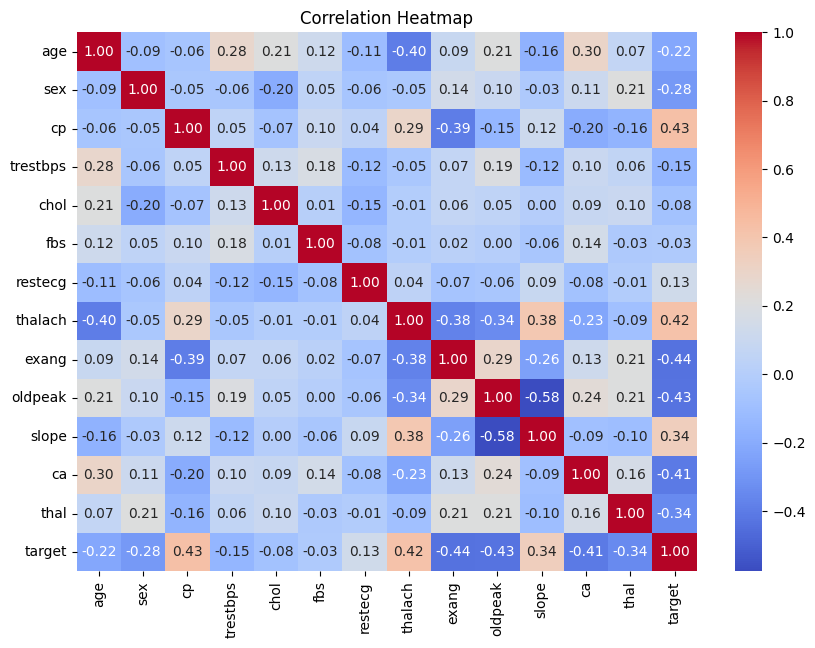

In [29]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing and Cleaning

In [30]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_label,cp_name,fbs_name
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Male,Typical Angina,<= 120 mg/dl
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Male,Typical Angina,>120 mg/dl
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Male,Typical Angina,<= 120 mg/dl
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Male,Typical Angina,<= 120 mg/dl
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Female,Typical Angina,>120 mg/dl


In [32]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [33]:
df_encoded

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_label_Male,cp_name_Atypical Angina,cp_name_Non-Anginal Pain,cp_name_Typical Angina,fbs_name_>120 mg/dl
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,True,False,False,True,False
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,True,False,False,True,True
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,True,False,False,True,False
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,True,False,False,True,False
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1,False,False,True,False,False
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1,False,False,True,False,False
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0,True,False,False,True,False
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0,True,False,False,False,False


In [34]:
df_encoded = df_encoded.astype(int)

In [35]:
df_encoded

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_label_Male,cp_name_Atypical Angina,cp_name_Non-Anginal Pain,cp_name_Typical Angina,fbs_name_>120 mg/dl
0,52,1,0,125,212,0,1,168,0,1,2,2,3,0,1,0,0,1,0
1,53,1,0,140,203,1,0,155,1,3,0,0,3,0,1,0,0,1,1
2,70,1,0,145,174,0,1,125,1,2,0,0,3,0,1,0,0,1,0
3,61,1,0,148,203,0,1,161,0,0,2,1,3,0,1,0,0,1,0
4,62,0,0,138,294,1,1,106,0,1,1,3,2,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1,1,0,2,1,0,0,1,0,0
733,44,0,2,108,141,0,1,175,0,0,1,0,2,1,0,0,1,0,0
739,52,1,0,128,255,0,1,161,1,0,2,1,3,0,1,0,0,1,0
843,59,1,3,160,273,0,0,125,0,0,2,0,2,0,1,0,0,0,0


In [36]:
df_encoded.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'sex_label_Male',
       'cp_name_Atypical Angina', 'cp_name_Non-Anginal Pain',
       'cp_name_Typical Angina', 'fbs_name_>120 mg/dl'],
      dtype='object')

In [37]:
x = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [38]:
x.head()
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

In [40]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# Model

In [41]:
from numpy.random import logistic
models = {
    'Logistic Regression' : LogisticRegression(),
    'KNN' : KNeighborsClassifier(),
    'Naive Bayes' : GaussianNB(),
    'Decision Tree' : DecisionTreeClassifier(),
    'SVM (RBF Kernel)' : SVC(probability = True)
}

In [42]:
results = []

In [43]:
for name, model in models.items():
  model.fit(x_train_scaled, y_train)
  y_pred = model.predict(x_test_scaled)
  acc = accuracy_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  results.append({
      'Model' : name,
      'Accuracy' : round(acc, 4),
      'F1 Score' : round(f1, 4)
  })

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



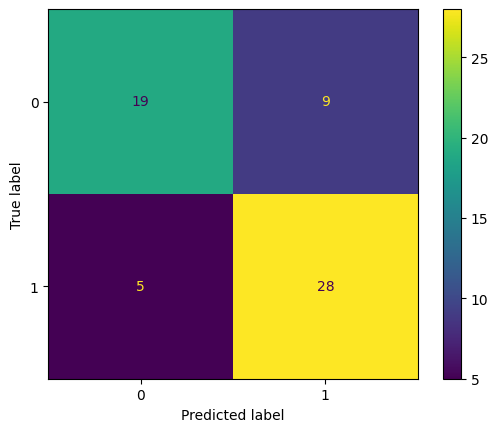

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [46]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.8033, 'F1 Score': 0.8333},
 {'Model': 'KNN', 'Accuracy': 0.7541, 'F1 Score': 0.7887},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8033, 'F1 Score': 0.8235},
 {'Model': 'Decision Tree', 'Accuracy': 0.7705, 'F1 Score': 0.7812},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.7705, 'F1 Score': 0.8}]

In [48]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']